In [9]:
import numpy as np
import matplotlib.pyplot as plt
import medal
import pickle

In [2]:
def generate_onion_correlation_matrix(d):
    R=np.zeros((d,d))
    R[0,0]=1.0

    for k in range(1, d):
        beta=(d-k) / 2.0
        y=np.random.beta(beta, beta)
        
        r=2*y-1
        
        w=np.random.normal(size=k)
        w=w/np.linalg.norm(w)
        
        P=np.sqrt(1-r**2)*w
        sub_matrix=R[:k, :k]
        U=np.linalg.cholesky(sub_matrix)
        c=U@P
        R[k, :k]=c
        R[:k, k]=c
        R[k, k]=1.0        
    return R

def build_covariance_matrix(d, std_devs):
    R=generate_onion_correlation_matrix(d)
    D=np.diag(std_devs)
    
    #covariance
    sigma=D@R@D
    return sigma

In [3]:
def random_orthonormal_svd(n, m):
    H=np.random.randn(m, n)
    U, S, Vt=np.linalg.svd(H, full_matrices=False)
    return U @ Vt #high_d x low_d

In [4]:
def append_noise(projected, noise_size):
    #add random noise feature
    noise=np.random.uniform(low=-1,high=1,size=(projected.shape[0],noise_size))
    projected=np.hstack((projected, noise))
    return projected

In [25]:
### gaussian mixture
rng=np.random.default_rng(seed=42)
noise=4
low_d=2
high_d=20
samp=1000

mu1=np.random.uniform(low=-1,high=1,size=low_d)   # coordinates uniformly sampled at random between -1, 1
stdv=np.random.uniform(low=-1,high=1,size=low_d) 
cov_matrix=build_covariance_matrix(low_d, stdv)
x0=rng.multivariate_normal(mu1, cov_matrix, samp) #samp x low_d

In [26]:
proj=random_orthonormal_svd(low_d, high_d)

In [29]:
sim1=append_noise(np.dot(x0,proj.T),3)

In [30]:
sim1

array([[ 2.28523202e-01,  1.83040344e-01,  6.94504416e-02, ...,
         9.12334031e-01,  6.19413544e-01,  5.31448425e-01],
       [-4.95838628e-02,  1.95864083e-02,  5.72369856e-02, ...,
        -3.00584668e-01,  2.92025628e-01,  5.99905153e-01],
       [ 2.57365067e-01, -5.94421093e-02, -2.45608678e-01, ...,
        -8.82288101e-01, -8.21594387e-01,  3.41114136e-01],
       ...,
       [ 2.54862798e-02,  3.72630180e-05, -1.70993733e-02, ...,
        -5.06685273e-01,  4.13924264e-01, -8.79742073e-02],
       [ 9.45653034e-02,  7.89957456e-02,  3.27041285e-02, ...,
        -8.49614970e-01, -3.52228632e-01,  9.24553391e-02],
       [-2.34112400e-01, -2.74035992e-01, -1.76640839e-01, ...,
        -7.31212140e-01,  8.81460031e-01, -7.27006653e-01]])

In [37]:
x0

array([[ 0.33131404, -0.54987846],
       [-0.45469841, -0.1431616 ],
       [ 2.08756091,  0.55620768],
       ...,
       [ 0.16848712,  0.02886152],
       [ 0.11611027, -0.24193777],
       [ 0.21909048,  0.94626363]])

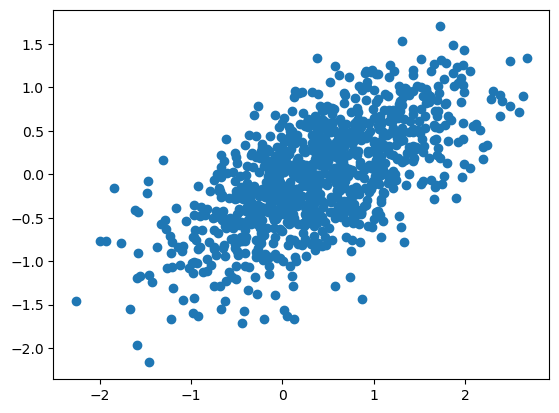

In [38]:
plt.scatter(x0[:,0],x0[:,1])

In [5]:
k=3
rng=np.random.default_rng(seed=42)
dataset=1
noise=4
low_d=2
high_d=20

samp_list=[200,300,200]
dataset_high=np.empty((0,high_d+noise))
dataset_low=np.empty((0,low_d))


for i in range(k):
    samp=samp_list[i]
    mu=np.random.uniform(low=-(i+1),high=(i+1),size=low_d)   # coordinates uniformly sampled at random between -1, 1
    stdv=np.random.uniform(low=-0.5,high=0.5,size=low_d) 
    cov_matrix=build_covariance_matrix(low_d, stdv)
    x0=rng.multivariate_normal(mu, cov_matrix, samp) #samp x low_d

    proj=random_orthonormal_svd(low_d, high_d)
    sim=append_noise(np.dot(x0,proj.T),noise)
    
    dataset_high=np.vstack((dataset_high, sim))
    dataset_low=np.vstack((dataset_low, x0))

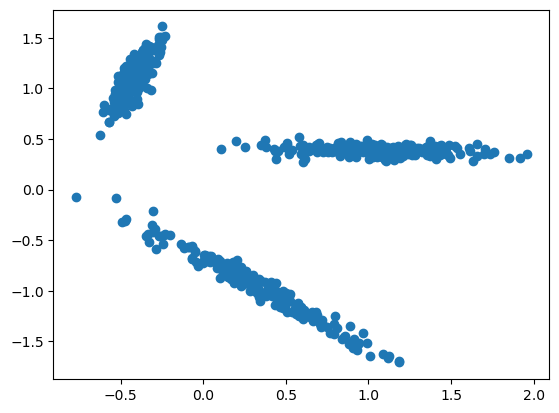

In [6]:
plt.scatter(dataset_low[:,0],dataset_low[:,1])

In [23]:
train=dataset_high[:600]
test=dataset_high[600:]
train.shape

(600, 24)

In [25]:
### find MEDAL architecture
result=medal.tune_medal_architecture(
    dataset_high,
    teacher="umap",
    teacher_params=None,
    output_dir="simulations-MEDAL/arch",
    latent_dim=2,
    search_space=None,
    search_mode="random",
    num_samples=8,
    resources_per_trial= None,
    metric= "distill_loss",
    mode= "min",
    scheduler=None,
    ray_storage_path= None,
    seed= 0,
    test_size= 0.2,
    max_epochs= 1000,
    save_results= True,
    verbose = True,
)
arch_config=result.to_arch_config()

2026-06-22 11:11:12,704	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-06-22 11:11:12,705	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-06-22 11:12:02,213	INFO tune.py:1001 -- Wrote the latest version of all result files and 

[tune_medal_architecture] Results saved to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/arch/arch_search_results.csv

Top 5 configs by distill_loss:
  1. distill_loss=1.3392e-06 | hidden_dims=[1024, 1024, 1024, 1024, 1024] | lr=1.00e-05 | lambda_d=1000
  2. distill_loss=5.7018e-06 | hidden_dims=[1024, 1024, 1024, 1024, 1024] | lr=5.00e-05 | lambda_d=1000
  3. distill_loss=6.5239e-05 | hidden_dims=[1024, 1024, 1024, 1024] | lr=1.00e-04 | lambda_d=5000
  4. distill_loss=1.2959e-04 | hidden_dims=[1024, 1024, 1024, 1024, 1024] | lr=1.00e-03 | lambda_d=5000
  5. distill_loss=1.7168e-04 | hidden_dims=[1024, 1024] | lr=1.00e-02 | lambda_d=500

ArchSearchResults(
  distill_loss=1.3392e-06
  hidden_dims=[1024, 1024, 1024, 1024, 1024],  lr=1e-05,  lambda_d=1000
  output_dir=/insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/arch
)


In [26]:
with open("simulations-MEDAL/reproduction/sim1-low.pkl","wb") as file:
    pickle.dump(dataset_low, file)
with open("simulations-MEDAL/reproduction/sim1-high.pkl","wb") as file:
    pickle.dump(dataset_high, file)
with open("simulations-MEDAL/reproduction/arch_config-1.pkl","wb") as file:
    pickle.dump(arch_config, file)

In [27]:
arch_config

{'max_epochs': 1000,
 'batch_size': 256,
 'warmup': 0,
 'eta_min': 1e-07,
 'adamw_weight_decay': 1e-05,
 't_factor': 0.9,
 't_patience': 20,
 'bottleneck_activation': None,
 'final_activation': None,
 'dropout_rate': 0.0,
 'hidden_dims': [1024, 1024, 1024, 1024, 1024],
 'lr': 1e-05,
 'lambda_d': 1000,
 'activation': 'SELU',
 'use_batchnorm': False}

In [28]:
sweep_results=medal.run_teacher_sweep(
    dataset_high, 
    output_dir="simulations-MEDAL/sweep",
    teacher="umap",
    arch_config=arch_config,
    param_grid=None,
    latent_dim=2,
    val_size=0.2,
    seeds=[0,1],
    normalize_teacher=True,
    distill_bands=None,
    resources_per_trial=None,
)

2026-06-22 11:12:28,378	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2026-06-22 11:12:28,379	WARNING tune_controller.py:2125 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (211 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.


(_sweep_trainable pid=2931896) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_5_seed0_ckpts/final.pt
(_sweep_trainable pid=2932607) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_9_seed0_ckpts/final.pt [repeated 4x across cluster]
(_sweep_trainable pid=2933313) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_18_seed0_ckpts/final.pt [repeated 4x across cluster]
(_sweep_trainable pid=2934008) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_35_seed0_ckpts/final.pt [repeated 4x across cluster]
(_sweep_trainable pid=2934714) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_69_seed0_ckpts/final.pt [repeated 4x across cluster]
(_sweep_trainable pid=2934879) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_96_seed0_ckpts/final.pt [repeated 2x across cluster]

2026-06-22 11:15:50,756	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/ray_results/medal_teacher_sweep' in 0.0248s.
2026-06-22 11:15:50,765	INFO tune.py:1033 -- Total run time: 202.39 seconds (202.35 seconds for the tuning loop).


(_sweep_trainable pid=2937002) Saved model to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/medal_umap2_499_seed1_ckpts/final.pt

Sweep summary saved to /insomnia001/depts/iicd/users/vj2308/simulations-MEDAL/sweep/sweep_summary_umap_sweep.csv
 n_neighbors  seed  final_distill_loss  final_recon_loss  n_epochs  early_stopped
           5     0            0.000002          0.021355      1000          False
           5     1            0.000002          0.021817      1000          False
           6     0            0.000002          0.025953      1000          False
           6     1            0.000005          0.026214      1000          False
           9     0            0.000001          0.024464       909           True
           9     1            0.000002          0.024651      1000          False
          13     0            0.000002          0.026542       999           True
          13     1            0.000001          0.026212      1000          False
    

In [29]:
df=sweep_results.load_metrics(dataset_high)

In [30]:
df

,n_neighbors,seed,split,recon_loss,distill_mse
0,5,0,Train,0.021949,0.000004
1,5,0,Val,0.035660,NaN
2,5,0,Test,0.024691,NaN
3,5,1,Train,0.022034,0.000006
4,5,1,Val,0.041037,NaN
...,...,...,...,...,...
85,499,0,Val,0.032076,NaN
86,499,0,Test,0.022062,NaN
87,499,1,Train,0.019547,0.000003
88,499,1,Val,0.032520,NaN


In [31]:
opt_param=medal.select_teacher_param(df, param_col="n_neighbors",
                                     metric_col="recon_loss",
                                     val_split="Val",
                                     distill_threshold=1e-5)

In [36]:
dataset_high.shape

(700, 24)

In [41]:
model=medal.MEDAL(
    input_dim=dataset_high.shape[1],
    latent_dim=2,
    hidden_dims=(1024,1024,1024,1024,1024),
    activation='SELU',
    lambda_d=1000,
    lr=1e-5,
    epochs=1000,
    batch_size=256,
    eta_min=1e-7,
    dropout_rate=0.0,
    adamw_weight_decay=1e-5
)
model=medal.MEDAL(
    input_dim=24,
    latent_dim=2,
    hidden_dims=(1024,1024))
teacher_embedding=medal.get_teacher_embeddings(
    "umap",
    dataset_high,
    n_neighbors=opt_param
)

/insomnia001/depts/iicd/users/vj2308/miniconda/envs/medal/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [42]:
model.fit(dataset_high, teacher_embedding)

100%|████████████████████████████████████████| 100/100 [00:04<00:00, 20.37it/s]


AttributeError: 'MEDAL' object has no attribute 'adamw_weight_decay'

AttributeError: 'MEDAL' object has no attribute 'adamw_weight_decay'

AttributeError: 'MEDAL' object has no attribute 'adamw_weight_decay'